Logistic Regression Accuracy: 89.20%

Tuning Random Forest... (This might take a few seconds)
Best Random Forest Accuracy: 93.13%
Best Parameters: {'max_depth': None, 'n_estimators': 100}

Classification Report (Best RF):

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       456
           1       0.96      0.94      0.95      1044

    accuracy                           0.93      1500
   macro avg       0.91      0.93      0.92      1500
weighted avg       0.93      0.93      0.93      1500



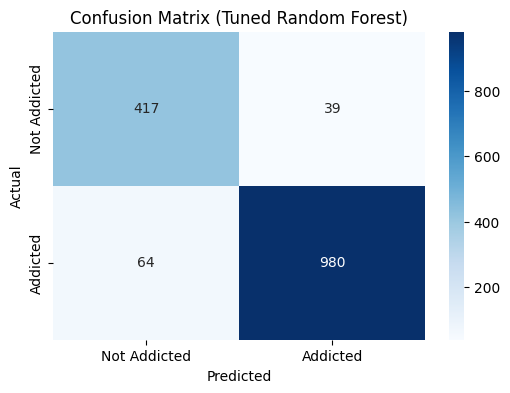

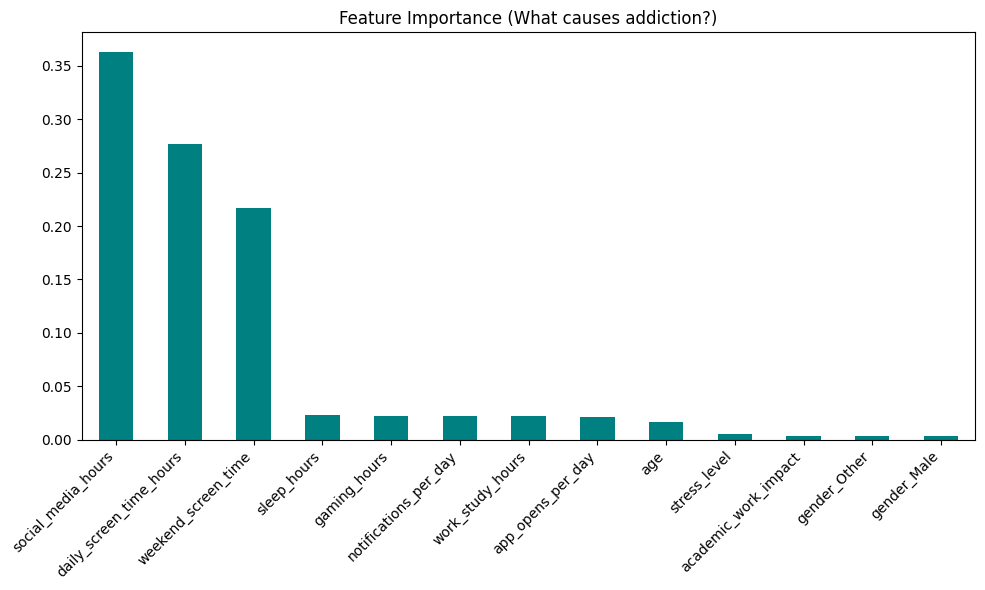

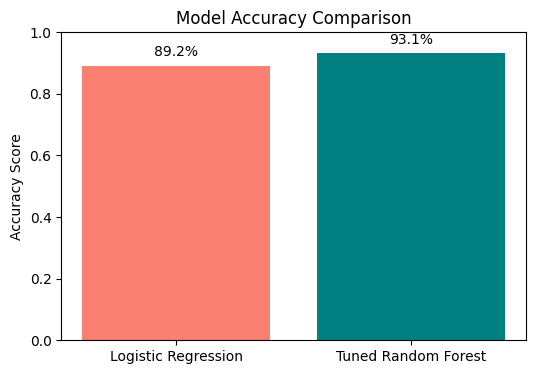

In [ ]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# STEP 2: LOAD DATASET
# ==============================
# (Assuming you uploaded the CSV directly rather than a zip file for the Bake-off)
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows 2.csv')

# ==============================
# STEP 3: CUSTOM DATA CLEANING
# ==============================
# Drop useless IDs and the duplicate target column BEFORE handling missing values
df_cleaned = df.drop(columns=['transaction_id', 'user_id', 'addiction_level'])

# Now it is safe to drop any remaining missing values if they exist
df_cleaned = df_cleaned.dropna()

# ==============================
# STEP 4: CUSTOM ENCODING
# ==============================
# Manually map ordinal data so the models understand the progression
df_cleaned['academic_work_impact'] = df_cleaned['academic_work_impact'].map({'No': 0, 'Yes': 1})
df_cleaned['stress_level'] = df_cleaned['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Use One-Hot Encoding for Gender (Creates separate columns instead of 0, 1, 2)
df_cleaned = pd.get_dummies(df_cleaned, columns=['gender'], drop_first=True)

# ==============================
# STEP 5: TARGET & SPLIT
# ==============================
X = df_cleaned.drop(columns=['addicted_label'])
y = df_cleaned['addicted_label']

# Scale the data (Crucial for Logistic Regression to perform fairly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==============================
# STEP 6: LOGISTIC REGRESSION (BASELINE)
# ==============================
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
log_acc = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {log_acc * 100:.2f}%")

# ==============================
# STEP 7: RANDOM FOREST & TUNING
# ==============================
# We use GridSearchCV just like in your code to find the best forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

print("\nTuning Random Forest... (This might take a few seconds)")
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
best_acc = accuracy_score(y_test, y_pred_best)

print(f"Best Random Forest Accuracy: {best_acc * 100:.2f}%")
print(f"Best Parameters: {grid.best_params_}")

# ==============================
# STEP 8: EVALUATION METRICS
# ==============================
print("\nClassification Report (Best RF):\n")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Addicted', 'Addicted'],
            yticklabels=['Not Addicted', 'Addicted'])
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# STEP 9: FEATURE IMPORTANCE
# ==============================
importance = best_rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar', color='teal')
plt.title("Feature Importance (What causes addiction?)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==============================
# STEP 10: MODEL COMPARISON GRAPH
# ==============================
models = ['Logistic Regression', 'Tuned Random Forest']
accuracy = [log_acc, best_acc]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracy, color=['salmon', 'teal'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1.0) # Set Y axis to 100%

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval*100:.1f}%", ha='center', va='bottom')

plt.show()